# PROJET D’OPTIMISATION COMBINATOIRE

## Cas 3 : Problème du sac à dos (Knapsack)

**Objectif :** Maximiser le profit sous contrainte de budget  
**Méthode :** Programmation linéaire en nombres entiers (PuLP)

---

## 1. Introduction

Dans ce cas d’étude, nous abordons un problème classique d’optimisation combinatoire, connu sous le nom de problème du sac à dos (Knapsack).

L’objectif est de sélectionner un ensemble de projets maximisant le profit total tout en respectant une contrainte de budget limitée.

Contrairement aux cas précédents, les variables de décision sont binaires, ce qui rend le problème plus complexe et plus proche des situations réelles.

## 2. Modélisation mathématique

### Variables de décision

Pour chaque projet i :
- xi = 1 si le projet est sélectionné
- xi = 0 sinon

### Fonction objectif

Maximiser :
Z = Σ (profit_i × xi)

### Contrainte

Σ (coût_i × xi) ≤ budget

### Nature du problème

Il s’agit d’un problème de programmation linéaire en nombres entiers binaires.

## 3. Données du problème

In [1]:
import pulp

projects = ["A", "B", "C", "D"]

profit = {"A": 10, "B": 7, "C": 15, "D": 8}
cost = {"A": 5, "B": 3, "C": 9, "D": 5}

budget = 15

print("Données chargées")

Données chargées


## 4. Implémentation du modèle (PuLP)

In [2]:
model = pulp.LpProblem("Knapsack", pulp.LpMaximize)

x = pulp.LpVariable.dicts("Choix", projects, cat="Binary")

# Fonction objectif
model += pulp.lpSum(profit[i] * x[i] for i in projects)

# Contrainte
model += pulp.lpSum(cost[i] * x[i] for i in projects) <= budget

## 5. Résolution du problème

In [3]:
model.solve()

1

## 6. Résultats obtenus

In [4]:
print("Statut :", pulp.LpStatus[model.status])

for i in projects:
    print(f"{i} =", x[i].varValue)

print("Profit total =", pulp.value(model.objective))

Statut : Optimal
A = 1.0
B = 1.0
C = 0.0
D = 1.0
Profit total = 25.0


## 7. Analyse des résultats

Le modèle sélectionne les projets permettant de maximiser le profit total tout en respectant la contrainte de budget.

Les variables binaires indiquent clairement quels projets sont retenus.

Ce résultat illustre l’intérêt de l’optimisation combinatoire dans les problèmes de sélection et d’allocation de ressources.

Le modèle met en évidence le compromis entre coût et profit, en choisissant les projets les plus rentables dans la limite du budget disponible.

## 8. Discussion

Le problème du sac à dos est un problème NP-difficile en optimisation combinatoire.

L’utilisation de solveurs comme PuLP permet de résoudre efficacement des instances de taille modérée.

Dans des cas réels, ce type de modèle peut être étendu à :
- la sélection de projets d’investissement
- l’allocation de ressources
- la gestion de portefeuille

Des variantes plus complexes peuvent inclure :
- plusieurs contraintes
- des dépendances entre projets
- des coûts variables

## 9. Conclusion

Ce cas d’étude a permis d’introduire les notions d’optimisation combinatoire à travers un problème concret.

L’utilisation de variables binaires permet de modéliser des décisions réelles.

Ce type d’approche est largement utilisé dans les domaines industriels, financiers et logistiques.

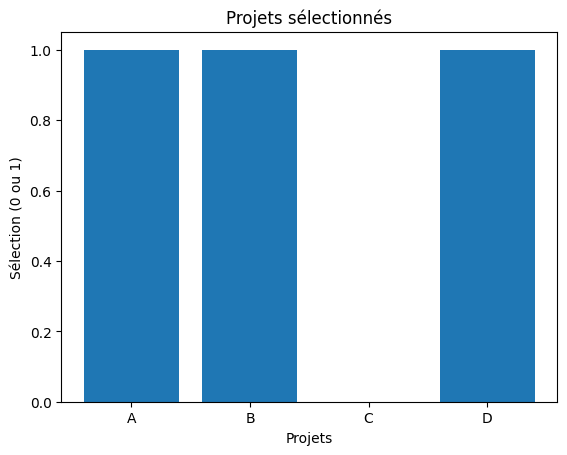

In [5]:
import matplotlib.pyplot as plt

labels = projects
values = [x[i].varValue for i in projects]

plt.bar(labels, values)
plt.title("Projets sélectionnés")
plt.xlabel("Projets")
plt.ylabel("Sélection (0 ou 1)")
plt.show()